## Downloading the dataset

In [15]:
import os
import urllib.parse
import urllib.request

# Download class list
os.makedirs("data", exist_ok=True)

categories_path = os.path.join("data", "categories.txt")

if not os.path.exists(categories_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/googlecreativelab/quickdraw-dataset/master/categories.txt",
        categories_path
    )

# Load all class names
with open(categories_path, "r") as f:
    all_categories = [line.strip() for line in f if line.strip()]

print(len(all_categories), "total categories")


345 total categories


In [17]:
# Randomly choose 50 classes

import random
import os

SEED = 42
NUM_CLASSES = 50

random.seed(SEED)
categories = random.sample(all_categories, NUM_CLASSES)

print(categories)

# Save chosen categories to txt
os.makedirs("data", exist_ok=True)

with open(os.path.join("data", "selected_categories.txt"), "w") as f:
    for cat in categories:
        f.write(cat + "\n")


['t-shirt', 'campfire', 'backpack', 'headphones', 'frog', 'fireplace', 'circle', 'calculator', 'square', 'broom', 'teapot', 'peas', 'baseball', 'barn', 'bus', 'fence', 'flip flops', 'sheep', 'The Eiffel Tower', 'banana', 'stitches', 'ear', 'violin', 'peanut', 'finger', 'pool', 'table', 'helicopter', 'ambulance', 'cow', 'lion', 'cooler', 'feather', 'lightning', 'mug', 'butterfly', 'mermaid', 'lobster', 'The Great Wall of China', 'hamburger', 'beach', 'rabbit', 'sock', 'castle', 'mouth', 'brain', 'stairs', 'hot dog', 'train', 'toothbrush']


In [18]:
# Download the chosen classes

import urllib.parse
import urllib.request
import os

os.makedirs(os.path.join("data", "quickdraw_npy"), exist_ok=True)
base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

for cat in categories:
    encoded = urllib.parse.quote(cat)
    url = base_url + encoded + ".npy"
    out_path = os.path.join("data", "quickdraw_npy", f"{cat}.npy")

    if os.path.exists(out_path):
        print(f"{cat} already exists — skipping")
        continue

    print(f"Downloading {cat}…")
    urllib.request.urlretrieve(url, out_path)


In [19]:
# Check for broken classes (0 mb files)
broken = False

for cat in categories:
    path = os.path.join("data", "quickdraw_npy", f"{cat}.npy")
    size = os.path.getsize(path)
    if size < 1000:
        print(f"{cat} is broken")
        broken = True

if not broken:
    print("All classes are good!")

All classes are good!


## Loading the dataset

In [ ]:
# Load and preprocess dataset

import torch
from torch.utils.data import Dataset
import numpy as np
import torchvision.transforms as transforms
import torch.nn.functional as F
import os

class QuickDrawDataset(Dataset):
    def __init__(self, files, split='train', train_frac=0.7, val_frac=0.15, test_frac=0.15,
                 image_size=28, binarize=True, augment=False, seed=42):
        """
        Memory-efficient Quick, Draw! dataset.
        Images are loaded from disk on-the-fly.
        """
        self.file_infos = []  # list of tuples (file_path, label, start_idx, end_idx)
        self.image_size = image_size
        self.binarize = binarize
        self.augment = augment
        rng = np.random.default_rng(seed)

        for label, file in enumerate(files):
            arr = np.load(file)  
            x_len = arr.shape[0]     
            del arr                      

            indices = np.arange(x_len)
            rng.shuffle(indices)

            n_train = int(train_frac * x_len)
            n_val   = int(val_frac * x_len)
            n_test  = x_len - n_train - n_val

            if split == 'train':
                split_indices = indices[:n_train]
            elif split == 'val':
                split_indices = indices[n_train:n_train+n_val]
            elif split == 'test':
                split_indices = indices[n_train+n_val:]
            else:
                raise ValueError("split must be 'train', 'val', or 'test'")

            self.file_infos.append((file, label, split_indices))


        # Flatten total number of samples
        self.total_len = sum(len(info[2]) for info in self.file_infos)

        # Augmentation transforms
        if self.augment:
            self.transform = transforms.Compose([
                transforms.RandomRotation(10),
                transforms.RandomAffine(0, translate=(0.05,0.05)),
            ])
        else:
            self.transform = None

    def __len__(self):
        return self.total_len

    def __getitem__(self, idx):
        for file_path, label, indices in self.file_infos:
            if idx < len(indices):
                sample_idx = indices[idx]
                break
            idx -= len(indices)
        else:
            raise IndexError("Index out of range")

        # Load flattened image and reshape
        image = np.load(file_path, mmap_mode='r')[sample_idx]
        image = image.reshape(28, 28).astype(np.float32) / 255.0

        # Binarize color (black and white)
        if self.binarize:
            image = (image > 0.1).astype(np.float32)

        image = torch.from_numpy(image).unsqueeze(0)  # [1, 28, 28]

        if self.image_size != 28:
            image = F.interpolate(
                image.unsqueeze(0),
                size=(self.image_size, self.image_size),
                mode='bilinear',
                align_corners=False
            ).squeeze(0)

        if self.transform:
            from torchvision.transforms import functional as TF
            image = TF.to_pil_image(image)
            image = self.transform(image)
            image = TF.to_tensor(image)

        return image, label


In [21]:
# Create the train/val/test split

files = [os.path.join("data", "quickdraw_npy", f"{cat}.npy") for cat in categories]

train_ds = QuickDrawDataset(files, split='train', augment=True)
val_ds   = QuickDrawDataset(files, split='val', augment=False)
test_ds  = QuickDrawDataset(files, split='test', augment=False)

print(len(train_ds), len(val_ds), len(test_ds))

5146391 1102780 1102850


### Visualize some preprocessed sample images

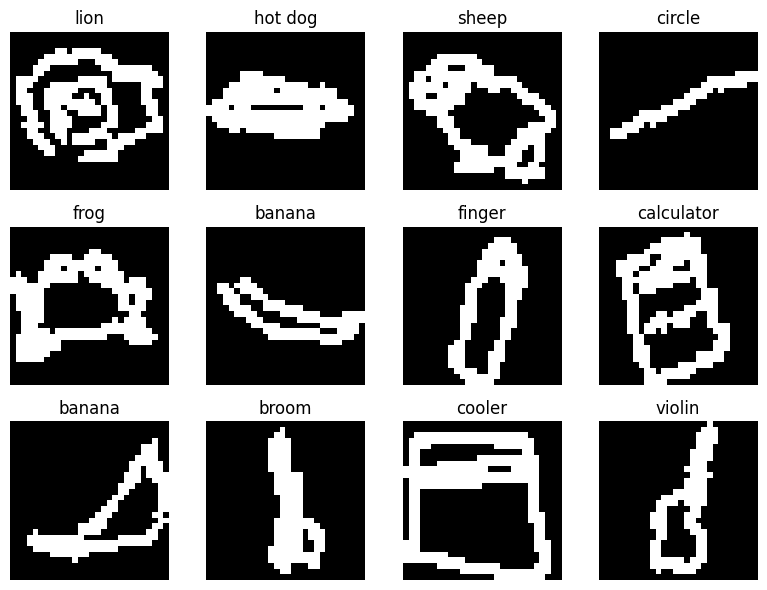

In [22]:
import matplotlib.pyplot as plt
import random
import os

def show_random_samples(dataset, categories, rows=3, cols=4):
    plt.figure(figsize=(cols*2, rows*2))

    for i in range(rows * cols):
        idx = random.randint(0, len(dataset) - 1)
        image, label = dataset[idx]

        image = image.squeeze(0).numpy()  # [H, W]

        plt.subplot(rows, cols, i+1)
        plt.imshow(image, cmap='gray', vmin=0, vmax=1)
        plt.title(categories[label])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

files = [os.path.join("data", "quickdraw_npy", f"{cat}.npy") for cat in categories]
train_ds = QuickDrawDataset(files, split='train', augment=True)

# Show random samples
show_random_samples(train_ds, categories, rows=3, cols=4)

## Create the model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class QuickDrawCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # 14×14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2), # 7×7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x) # [B,128,7,7]
        x = F.adaptive_avg_pool2d(x, 1) # [B,128,1,1]
        x = x.view(x.size(0), -1) # [B,128]
        return self.classifier(x)


In [24]:
# Instantiate model
model = QuickDrawCNN(num_classes=50)
sum(p.numel() for p in model.parameters())

99570

## Training

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = QuickDrawCNN(num_classes=len(categories)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [26]:
# Dataloader

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

In [27]:
# Create training loop

from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{running_loss / total:.4f}",
            "acc":  f"{correct / total:.3f}"
        })

    return running_loss / total, correct / total

def eval_epoch(model, loader, epoch, num_epochs):
    model.eval()
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({
                "acc": f"{correct / total:.3f}"
            })

    return correct / total

c:\Projects\quickdraw_game\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
os.makedirs("models", exist_ok=True)  # Make sure models folder exists

# Train
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, epoch, num_epochs
    )
    val_acc = eval_epoch(
        model, val_loader, epoch, num_epochs
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"| train_loss={train_loss:.4f} "
        f"| train_acc={train_acc:.3f} "
        f"| val_acc={val_acc:.3f}"
    )

    # Save model after every epoch
    save_path = os.path.join("models", f"quickdraw_epoch{epoch+1}.pt")
    torch.save(model.state_dict(), save_path)
    print(f"Saved model to {save_path}")

### Save and load the model

In [ ]:
import os
os.makedirs("models", exist_ok=True)

save_path = os.path.join("models", "quickdraw_cnn.pt")
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

In [29]:
import os

load_path = os.path.join("models", "quickdraw_cnn.pt")
model = QuickDrawCNN(num_classes=len(categories))
model.load_state_dict(torch.load(load_path, map_location=device))
model.to(device)
model.eval()

QuickDrawCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Linear(in_features=128, out_features=50, bias=True)
)

## Test the model

In [ ]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

In [31]:
from tqdm.auto import tqdm

# Evaluate model accuracy on test data
def evaluate_test(model, loader):
    model.eval()
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Evaluating on TEST set")

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({
                "acc": f"{correct / total:.4f}"
            })

    return correct / total

test_acc = evaluate_test(model, test_loader)
print(f"\nFinal TEST accuracy: {test_acc:.4f}")

Evaluating on TEST set: 100%|██████████| 4309/4309 [06:29<00:00, 11.05it/s, acc=0.8306]


Final TEST accuracy: 0.8306


In [ ]:
# Evaluate top-k accuracy
def evaluate_topk(model, loader, k=3):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            topk = logits.topk(k, dim=1).indices

            correct += (topk == labels.unsqueeze(1)).any(dim=1).sum().item()
            total += labels.size(0)

    return correct / total

top3_acc = evaluate_topk(model, test_loader, k=3)
print(f"Top-3 TEST accuracy: {top3_acc:.4f}")

Top-3 TEST accuracy: 0.9309
